# Data Cleaning & Loading in Database

In [1]:
# importing the required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# loading the datasets

#dim_campaigns
df_1 = pd.read_csv(r"X:\00 Portfolio Projects\00 New Projects\For Resume\SQL + Power BI Retail Industry Analysis\Project Files\working data\raw data\dim_campaigns.csv")

#dim_products
df_2 = pd.read_csv(r"X:\00 Portfolio Projects\00 New Projects\For Resume\SQL + Power BI Retail Industry Analysis\Project Files\working data\raw data\dim_products.csv")

#dim_stores
df_3 = pd.read_csv(r"X:\00 Portfolio Projects\00 New Projects\For Resume\SQL + Power BI Retail Industry Analysis\Project Files\working data\raw data\dim_stores.csv")

#fact_events
df_4 = pd.read_csv(r"X:\00 Portfolio Projects\00 New Projects\For Resume\SQL + Power BI Retail Industry Analysis\Project Files\working data\raw data\fact_events.csv")

### Data Cleaning dim_campaigns

In [3]:
# overview of the data

df_1.head(10)

,campaign_id,campaign_name,start_date,end_date
0,CAMP_DIW_01,Diwali,12-11-2023,18-11-2023
1,CAMP_SAN_01,Sankranti,10-01-2024,16-01-2024


In [4]:
# overview of dataset information

df_1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   campaign_id    2 non-null      object
 1   campaign_name  2 non-null      object
 2   start_date     2 non-null      object
 3   end_date       2 non-null      object
dtypes: object(4)
memory usage: 196.0+ bytes


**dim_campaign has no errors and it is ready for import**

### Data Cleaning dim_products

In [5]:
# overview of the data

df_2.head(10)

,product_code,product_name,category
0,P01,Atliq_Masoor_Dal (1KG),Grocery & Staples
1,P02,Atliq_Sonamasuri_Rice (10KG),Grocery & Staples
2,P03,Atliq_Suflower_Oil (1L),Grocery & Staples
3,P04,Atliq_Farm_Chakki_Atta (1KG),Grocery & Staples
4,P05,Atliq_Scrub_Sponge_For_Dishwash,Home Care
5,P06,Atliq_Fusion_Container_Set_of_3,Home Care
6,P09,Atliq_Body_Milk_Nourishing_Lotion (120ML),Personal Care
7,P10,Atliq_Cream_Beauty_Bathing_Soap (125GM),Personal Care
8,P13,Atliq_High_Glo_15W_LED_Bulb,Home Appliances
9,P14,Atliq_waterproof_Immersion_Rod,Home Appliances


In [6]:
df_2.shape

(18, 3)

In [7]:
# checking for duplicates

df_2.duplicated().sum()

np.int64(3)

**There are 3 duplicates in this dataset**

In [8]:
# removing the duplicates

df_2.drop_duplicates(inplace=True)

In [9]:
df_2.shape

(15, 3)

In [10]:
# overview of dataset information

df_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15 entries, 0 to 14
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   product_code  15 non-null     object
 1   product_name  15 non-null     object
 2   category      15 non-null     object
dtypes: object(3)
memory usage: 480.0+ bytes


In [11]:
# Checking the value counts for the categorical columns

categorical_cols = [
    col for col in df_2.select_dtypes(include=["object", "category"]).columns
    if not col.endswith("_id")
]

for col in categorical_cols:
    print(f"\n\nValue counts for {col}:")
    print(df_2[col].value_counts(dropna=False))



Value counts for product_code:
product_code
P01    1
P02    1
P03    1
P04    1
P05    1
P06    1
P09    1
P10    1
P13    1
P14    1
P11    1
P12    1
P07    1
P08    1
P15    1
Name: count, dtype: int64


Value counts for product_name:
product_name
Atliq_Masoor_Dal (1KG)                       1
Atliq_Sonamasuri_Rice (10KG)                 1
Atliq_Suflower_Oil (1L)                      1
Atliq_Farm_Chakki_Atta (1KG)                 1
Atliq_Scrub_Sponge_For_Dishwash              1
Atliq_Fusion_Container_Set_of_3              1
Atliq_Body_Milk_Nourishing_Lotion (120ML)    1
Atliq_Cream_Beauty_Bathing_Soap (125GM)      1
Atliq_High_Glo_15W_LED_Bulb                  1
Atliq_waterproof_Immersion_Rod               1
Atliq_Doodh_Kesar_Body_Lotion (200ML)        1
Atliq_Lime_Cool_Bathing_Bar (125GM)          1
Atliq_Curtains                               1
Atliq_Double_Bedsheet_set                    1
Atliq_Home_Essential_8_Product_Combo         1
Name: count, dtype: int64


Value counts f

**dim_products has no more errors and it is ready for import**

### Data Cleaning dim_stores

In [12]:
# overview of the data

df_3.head(10)

,store_id,city
0,STTRV-0,Trivandrum
1,STMDU-3,Madurai
2,STHYD-6,Hyderabad
3,STVSK-1,Visakhapatnam
4,STCBE-3,Coimbatore
5,STBLR-8,Bengaluru
6,STBLR-2,Bengaluru
7,STCHE-7,Chennai
8,STCBE-0,Coimbatore
9,STVSK-0,Visakhapatnam


In [13]:
df_3.shape

(58, 2)

In [14]:
# checking for duplicates

df_3.duplicated().sum()

np.int64(8)

**There are 8 duplicates in this dataset**

In [15]:
# removing the duplicates

df_3.drop_duplicates(inplace=True)

In [16]:
df_3.shape

(50, 2)

In [17]:
# overview of dataset information

df_3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50 entries, 0 to 49
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   store_id  50 non-null     object
 1   city      50 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


In [18]:
# Checking the value counts for the categorical columns

categorical_cols = [
    col for col in df_3.select_dtypes(include=["object", "category"]).columns
    if not col.endswith("_id")
]

for col in categorical_cols:
    print(f"\n\nValue counts for {col}:")
    print(df_3[col].value_counts(dropna=False))



Value counts for city:
city
Bengaluru              9
Chennai                7
Hyderabad              6
Coimbatore             4
Madurai                4
Visakhapatnam          4
Mangalore              3
Mysuru                 2
   Vijayawada          2
   Mysuru              2
Trivandrum             1
   Chennai             1
   Visakhapatnam       1
   Bengaluru           1
   Trivandrum          1
   Hyderabad           1
   Coimbatore          1
Name: count, dtype: int64


**There are leading and trailing whitespaces in the names of city**

In [19]:
# removing leading and trailing whitespaces in city column

df_3["city"] = df_3["city"].str.strip()

In [20]:
df_3["city"].value_counts()

city
Bengaluru        10
Chennai           8
Hyderabad         7
Visakhapatnam     5
Coimbatore        5
Madurai           4
Mysuru            4
Mangalore         3
Trivandrum        2
Vijayawada        2
Name: count, dtype: int64

**dim_stores has no more errors and is ready for import**

### Data Cleaning fact_events

In [21]:
# overview of the data

df_4.head(20)

,event_id,store_id,campaign_id,product_code,base_price,promo_type,quantity_sold(before_promo),quantity_sold(after_promo)
0,7f650b,STCBE-2,CAMP_SAN_01,P11,190.00,50% OFF,34.0,52.0
1,a21f91,STBLR-8,CAMP_DIW_01,P03,156,25% OFF,393.0,322.0
2,78bc80,STVJD-0,CAMP_SAN_01,P07,300,BOGOF,NaN,85.0
3,a1503f,STCBE-1,CAMP_DIW_01,P15,3000,500 Cashback,329.0,1000.0
4,1091cf,STBLR-6,CAMP_DIW_01,P05,55.00,25% OFF,108.0,93.0
5,8.02E+96,STBLR-4,CAMP_DIW_01,P11,190.00,50% OFF,91.0,116.0
6,73d86f,STVSK-2,CAMP_SAN_01,P10,50,25% OFF,31.0,26.0
7,fe3560,STHYD-4,CAMP_DIW_01,P13,350,BOGOF,73.0,245.0
8,6b2afc,STCBE-4,CAMP_SAN_01,P08,NaN,BOGOF,30.0,79.0
9,ce5851,STMDU-2,CAMP_SAN_01,P03,200,BOGOF,318.0,1265.0


In [22]:
df_4.shape

(1513, 8)

In [23]:
# checking for duplicates

df_4.duplicated().sum()

np.int64(13)

**There are 13 duplicates in this dataset**

In [24]:
# removing duplicates

df_4.drop_duplicates(inplace=True)

In [25]:
df_4.shape

(1500, 8)

**Removed the duplicates**

In [26]:
# overview of dataset information

df_4.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1500 entries, 0 to 1499
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   event_id                     1500 non-null   object 
 1   store_id                     1500 non-null   object 
 2   campaign_id                  1500 non-null   object 
 3   product_code                 1500 non-null   object 
 4   base_price                   1373 non-null   object 
 5   promo_type                   1500 non-null   object 
 6   quantity_sold(before_promo)  1436 non-null   float64
 7   quantity_sold(after_promo)   1478 non-null   float64
dtypes: float64(2), object(6)
memory usage: 105.5+ KB


In [27]:
# checking the value counts for the categorical columns

categorical_cols = [
    col for col in df_4.select_dtypes(include=["object", "category"]).columns
    if not col.endswith("_id")
]

for col in categorical_cols:
    print(f"\n\nValue counts for {col}:")
    print(df_4[col].value_counts(dropna=False))



Value counts for product_code:
product_code
P11    100
P03    100
P07    100
P15    100
P05    100
P10    100
P13    100
P08    100
P06    100
P12    100
P04    100
P02    100
P01    100
P14    100
P09    100
Name: count, dtype: int64


Value counts for base_price:
base_price
NaN          127
415           73
860           72
1190          70
172           70
            ... 
Rs.55.00       1
Rs.415.00      1
Rs.62.00       1
Rs.370.00      1
Rs.50          1
Name: count, Length: 74, dtype: int64


Value counts for promo_type:
promo_type
BOGOF           480
25% OFF         382
50% OFF         295
33% OFF         189
500 Cashback    100
B1G1F            20
25% off          18
33% off          11
50% off           5
Name: count, dtype: int64


* **There are null values in base_price, quantity_sold(before_promo), quantity_sold(after_promo) columns.**
* **There is irregularity in the entries of promo_type and base_price such as difference in cases, different abbreviation, irregular prefix and suffix.**
* **The data type of base_price, quantity_sold(before_promo) and quantity_sold(after_promo) are wrong. base_price should be int or float and for qty_sold, int data type is more appropriate.**

In [28]:
# Removing "Rs." prefix and ".00" suffix from base_price column

df_4["base_price"] = (
    df_4["base_price"]
        .str.replace("Rs.", "", regex=False)
        .str.replace(".00", "", regex=False)
)

df_4.tail(10)

,event_id,store_id,campaign_id,product_code,base_price,promo_type,quantity_sold(before_promo),quantity_sold(after_promo)
1490,b92097,STCBE-4,CAMP_DIW_01,P03,156,25% OFF,257.0,221.0
1491,ffb109,STVSK-2,CAMP_DIW_01,P15,3000,500 Cashback,204.0,589.0
1492,11578,STHYD-3,CAMP_SAN_01,P14,1020,BOGOF,NaN,236.0
1493,a0017b,STCBE-4,CAMP_SAN_01,P05,NaN,25% OFF,16.0,12.0
1494,ac0db6,STBLR-8,CAMP_SAN_01,P06,415,25% OFF,22.0,16.0
1495,1e8961,STBLR-3,CAMP_SAN_01,P12,62,50% OFF,61.0,84.0
1496,f957f1,STMDU-1,CAMP_SAN_01,P10,50,25% OFF,22.0,18.0
1497,a9ae21,STCBE-0,CAMP_DIW_01,P12,62,50% OFF,80.0,119.0
1498,e5d28d,STVSK-0,CAMP_SAN_01,P13,350,BOGOF,73.0,282.0
1499,4d22d1,STBLR-9,CAMP_SAN_01,P12,62,50% OFF,52.0,73.0


**Removed irregular prefix 'Rs.' and suffix '.00' from base_price**

In [29]:
# checking if each product_code has only one unique base_price value

df_4.groupby("product_code")["base_price"].nunique()

product_code
P01    1
P02    1
P03    2
P04    2
P05    1
P06    1
P07    1
P08    1
P09    2
P10    2
P11    1
P12    1
P13    1
P14    1
P15    1
Name: base_price, dtype: int64

In [30]:
# checking the base_price for product_code 3, 4, 9 and 10

df_4[df_4["product_code"] == "P03"]

,event_id,store_id,campaign_id,product_code,base_price,promo_type,quantity_sold(before_promo),quantity_sold(after_promo)
1,a21f91,STBLR-8,CAMP_DIW_01,P03,156,25% OFF,393.0,322.0
9,ce5851,STMDU-2,CAMP_SAN_01,P03,200,BOGOF,318.0,1265.0
25,b08c12,STMDU-3,CAMP_DIW_01,P03,156,25% OFF,227.0,202.0
36,f3ac85,STBLR-5,CAMP_SAN_01,P03,200,B1G1F,348.0,1350.0
38,620715,STMYS-3,CAMP_SAN_01,P03,200,BOGOF,340.0,1485.0
...,...,...,...,...,...,...,...,...
1419,a0da88,STMLR-2,CAMP_DIW_01,P03,156,25% OFF,204.0,NaN
1448,4dcb0e,STBLR-8,CAMP_SAN_01,P03,200,BOGOF,360.0,1414.0
1463,3edc10,STVSK-1,CAMP_DIW_01,P03,156,25% OFF,246.0,194.0
1479,136c14,STHYD-1,CAMP_SAN_01,P03,200,BOGOF,328.0,833.0


In [31]:
df_4[df_4["product_code"] == "P04"]

,event_id,store_id,campaign_id,product_code,base_price,promo_type,quantity_sold(before_promo),quantity_sold(after_promo)
13,d290a1,STBLR-3,CAMP_DIW_01,P04,290,25% OFF,343.0,270.0
37,292ca5,STHYD-2,CAMP_DIW_01,P04,290,25% OFF,287.0,220.0
54,4.47E+06,STVJD-0,CAMP_SAN_01,P04,370,BOGOF,253.0,1017.0
62,3b54c7,STHYD-3,CAMP_DIW_01,P04,290,25% OFF,367.0,297.0
67,d304f9,STCHE-5,CAMP_DIW_01,P04,290,25% OFF,309.0,268.0
...,...,...,...,...,...,...,...,...
1443,c9fa13,STHYD-4,CAMP_SAN_01,P04,370,BOGOF,403.0,1567.0
1449,f304a8,STMYS-1,CAMP_DIW_01,P04,290,25% OFF,204.0,157.0
1450,9b5299,STBLR-6,CAMP_DIW_01,P04,290,25% OFF,360.0,320.0
1465,3b4a4f,STBLR-0,CAMP_DIW_01,P04,290,25% OFF,337.0,296.0


In [32]:
df_4[df_4["product_code"] == "P09"]

,event_id,store_id,campaign_id,product_code,base_price,promo_type,quantity_sold(before_promo),quantity_sold(after_promo)
31,ca3893,STMYS-1,CAMP_SAN_01,P09,90,25% OFF,52.0,39.0
74,ad56bd,STMLR-2,CAMP_DIW_01,P09,110,50% OFF,36.0,37.0
76,eaa64b,STBLR-3,CAMP_SAN_01,P09,90,25% OFF,58.0,43.0
91,e9c690,STMDU-3,CAMP_SAN_01,P09,90,25% OFF,45.0,38.0
129,9c74f7,STBLR-9,CAMP_DIW_01,P09,NaN,50% OFF,71.0,90.0
...,...,...,...,...,...,...,...,...
1432,26e506,STCHE-0,CAMP_SAN_01,P09,90,25% OFF,72.0,59.0
1466,0ffbbc,STTRV-1,CAMP_SAN_01,P09,90,25% OFF,30.0,28.0
1470,be603f,STHYD-1,CAMP_DIW_01,P09,110,50% OFF,NaN,92.0
1474,e716e7,STBLR-7,CAMP_DIW_01,P09,110,50% OFF,78.0,117.0


In [33]:
df_4[df_4["product_code"] == "P10"]

,event_id,store_id,campaign_id,product_code,base_price,promo_type,quantity_sold(before_promo),quantity_sold(after_promo)
6,73d86f,STVSK-2,CAMP_SAN_01,P10,50,25% OFF,31.0,26.0
53,a85a9a,STHYD-2,CAMP_SAN_01,P10,50,25% OFF,42.0,31.0
56,29524a,STBLR-9,CAMP_SAN_01,P10,50,25% OFF,40.0,36.0
66,7634c0,STMLR-0,CAMP_SAN_01,P10,NaN,25% OFF,15.0,12.0
72,1c1cb7,STHYD-5,CAMP_SAN_01,P10,50,25% OFF,39.0,35.0
...,...,...,...,...,...,...,...,...
1441,d04921,STMLR-1,CAMP_DIW_01,P10,65,50% OFF,50.0,NaN
1445,20eb36,STCBE-1,CAMP_DIW_01,P10,65,50% OFF,NaN,92.0
1446,166ffe,STMYS-1,CAMP_SAN_01,P10,50,25% OFF,28.0,20.0
1467,08086d,STBLR-7,CAMP_DIW_01,P10,NaN,50% OFF,120.0,188.0


In [34]:
# checking if there are unique base_price for each product_code as per each campaign_id

df_4.groupby(["campaign_id", "product_code"])["base_price"].nunique()

campaign_id  product_code
CAMP_DIW_01  P01             1
             P02             1
             P03             1
             P04             1
             P05             1
             P06             1
             P07             1
             P08             1
             P09             1
             P10             1
             P11             1
             P12             1
             P13             1
             P14             1
             P15             1
CAMP_SAN_01  P01             1
             P02             1
             P03             1
             P04             1
             P05             1
             P06             1
             P07             1
             P08             1
             P09             1
             P10             1
             P11             1
             P12             1
             P13             1
             P14             1
             P15             1
Name: base_price, dtype: int64

In [35]:
# filling the nulls in base_price by mapping the values using unique base price fpr each campaign for each product

df_4["base_price"] = df_4["base_price"].fillna(
    df_4.groupby(["campaign_id", "product_code"])["base_price"]
      .transform("first")
)


In [36]:
df_4[df_4["product_code"] == "P10"]

,event_id,store_id,campaign_id,product_code,base_price,promo_type,quantity_sold(before_promo),quantity_sold(after_promo)
6,73d86f,STVSK-2,CAMP_SAN_01,P10,50,25% OFF,31.0,26.0
53,a85a9a,STHYD-2,CAMP_SAN_01,P10,50,25% OFF,42.0,31.0
56,29524a,STBLR-9,CAMP_SAN_01,P10,50,25% OFF,40.0,36.0
66,7634c0,STMLR-0,CAMP_SAN_01,P10,50,25% OFF,15.0,12.0
72,1c1cb7,STHYD-5,CAMP_SAN_01,P10,50,25% OFF,39.0,35.0
...,...,...,...,...,...,...,...,...
1441,d04921,STMLR-1,CAMP_DIW_01,P10,65,50% OFF,50.0,NaN
1445,20eb36,STCBE-1,CAMP_DIW_01,P10,65,50% OFF,NaN,92.0
1446,166ffe,STMYS-1,CAMP_SAN_01,P10,50,25% OFF,28.0,20.0
1467,08086d,STBLR-7,CAMP_DIW_01,P10,65,50% OFF,120.0,188.0


In [37]:
df_4["base_price"].isnull().sum()

np.int64(0)

In [38]:
# changing base_price datatype to int

df_4["base_price"] = df_4["base_price"].astype(int)

In [39]:
df_4["base_price"].info

<bound method Series.info of 0        190
1        156
2        300
3       3000
4         55
        ... 
1495      62
1496      50
1497      62
1498     350
1499      62
Name: base_price, Length: 1500, dtype: int64>

**Filled the null values in base_price column by mapping exact prices using campaign_id and product_code. Also, changed the datatype to int.**

In [40]:
# removing the irregularity in the entries of promo_type column

df_4["promo_type"] = (
    df_4["promo_type"]
        .str.upper()
        .replace("B1G1F", "BOGOF")
)

In [41]:
df_4["promo_type"].unique()

array(['50% OFF', '25% OFF', 'BOGOF', '500 CASHBACK', '33% OFF'],
      dtype=object)

**Fixed the data irregularity in promo_type column**

In [42]:
# converting quantity_sold(before_promo) to float datatype

df_4["quantity_sold(before_promo)"] = pd.to_numeric(df_4["quantity_sold(before_promo)"], errors = "coerce")

In [43]:
# filling null values in quantity_sold(before_promo) using camapign wise median values of each product

df_4["quantity_sold(before_promo)"] = df_4["quantity_sold(before_promo)"].fillna(
    df_4.groupby(["campaign_id", "product_code"])["quantity_sold(before_promo)"]
      .transform("median")
)

In [44]:
df_4["quantity_sold(before_promo)"].isnull().sum()

np.int64(0)

In [45]:
df_4["quantity_sold(before_promo)"] = df_4["quantity_sold(before_promo)"].astype(int)

In [46]:
df_4["quantity_sold(before_promo)"].info

<bound method Series.info of 0        34
1       393
2        40
3       329
4       108
       ... 
1495     61
1496     22
1497     80
1498     73
1499     52
Name: quantity_sold(before_promo), Length: 1500, dtype: int64>

**Filled the null values in quantity_sold(before_promo) column by campaign and product specific median values. Also, changed the datatype to int.**

In [47]:
# converting quantity_sold(after_promo) to float datatype

df_4["quantity_sold(after_promo)"] = pd.to_numeric(df_4["quantity_sold(after_promo)"], errors = "coerce")

In [48]:
# filling null values in quantity_sold(after_promo) using camapign wise median values of each product

df_4["quantity_sold(after_promo)"] = df_4["quantity_sold(after_promo)"].fillna(
    df_4.groupby(["campaign_id", "product_code"])["quantity_sold(after_promo)"]
      .transform("median")
)

In [49]:
df_4["quantity_sold(after_promo)"].isnull().sum()

np.int64(0)

In [50]:
df_4["quantity_sold(after_promo)"] = df_4["quantity_sold(after_promo)"].astype(int)

In [51]:
df_4["quantity_sold(after_promo)"].info

<bound method Series.info of 0         52
1        322
2         85
3       1000
4         93
        ... 
1495      84
1496      18
1497     119
1498     282
1499      73
Name: quantity_sold(after_promo), Length: 1500, dtype: int64>

**Filled the null values in quantity_sold(after_promo) column by campaign and product specific median values. Also, changed the datatype to int.**

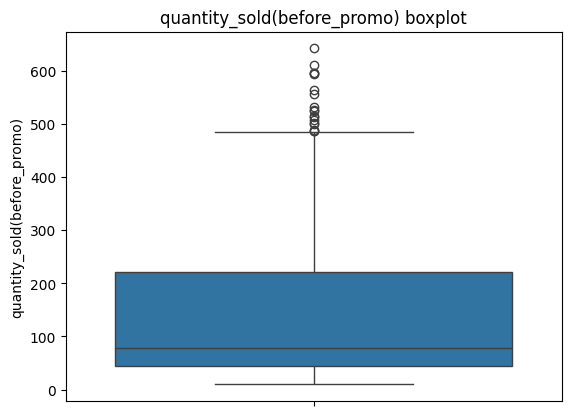

In [52]:
# checking for outliers in quantity_sold(before_promo) column with boxplot

plt.figure()
sns.boxplot(y=df_4["quantity_sold(before_promo)"])
plt.title("quantity_sold(before_promo) boxplot")
plt.show()

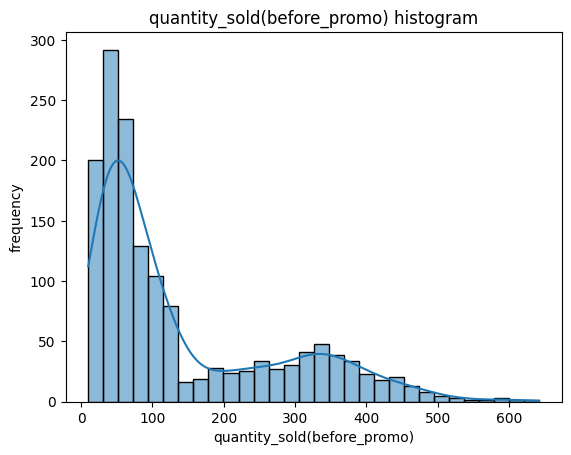

In [53]:
# checking for outliers in quantity_sold(before_promo) column with histogram

plt.figure()
sns.histplot(df_4["quantity_sold(before_promo)"], bins = 30, kde = True)
plt.title("quantity_sold(before_promo) histogram")
plt.xlabel("quantity_sold(before_promo)")
plt.ylabel("frequency")
plt.show()

In [54]:
df_4["quantity_sold(before_promo)"].max()

np.int64(642)

In [55]:
df_4.nlargest(10, "quantity_sold(before_promo)")

,event_id,store_id,campaign_id,product_code,base_price,promo_type,quantity_sold(before_promo),quantity_sold(after_promo)
849,400cab,STCHE-4,CAMP_SAN_01,P02,860,33% OFF,642,918
509,b0cc1e,STBLR-9,CAMP_SAN_01,P02,860,33% OFF,610,847
365,6ee2af,STHYD-3,CAMP_SAN_01,P02,860,33% OFF,595,892
1197,c649ca,STMYS-1,CAMP_SAN_01,P02,860,33% OFF,595,886
791,0d853d,STHYD-4,CAMP_SAN_01,P02,860,33% OFF,594,819
439,4f40ed,STCHE-5,CAMP_SAN_01,P02,860,33% OFF,564,721
385,607c9d,STCHE-2,CAMP_SAN_01,P02,860,33% OFF,556,711
634,269cec,STBLR-6,CAMP_SAN_01,P02,860,33% OFF,532,813
705,4cc388,STBLR-7,CAMP_SAN_01,P02,860,33% OFF,526,799
412,b526b4,STCHE-7,CAMP_SAN_01,P02,860,33% OFF,525,756


In [56]:
df_4["quantity_sold(before_promo)"].min()

np.int64(10)

In [57]:
df_4.nsmallest(10, "quantity_sold(before_promo)")

,event_id,store_id,campaign_id,product_code,base_price,promo_type,quantity_sold(before_promo),quantity_sold(after_promo)
455,f88523,STTRV-1,CAMP_SAN_01,P05,55,25% OFF,10,9
860,5e59a1,STTRV-0,CAMP_SAN_01,P05,55,25% OFF,12,11
867,dafaa4,STVJD-1,CAMP_SAN_01,P05,55,25% OFF,13,9
1216,65a802,STMLR-1,CAMP_SAN_01,P05,55,25% OFF,13,10
1321,86196b,STTRV-0,CAMP_SAN_01,P06,415,25% OFF,13,11
1422,bed4b4,STMLR-1,CAMP_SAN_01,P10,50,25% OFF,13,10
66,7634c0,STMLR-0,CAMP_SAN_01,P10,50,25% OFF,15,12
100,8b751b,STMLR-0,CAMP_SAN_01,P05,55,25% OFF,15,12
356,94953c,STMLR-2,CAMP_SAN_01,P06,415,25% OFF,15,12
484,00af86,STCBE-0,CAMP_SAN_01,P06,415,25% OFF,15,14


**From the above graphs and observations it is clear that although there are some outliers in quantity_sold(before_promo) column but they represent real world scenario, so there is no need to alter or remove them.**

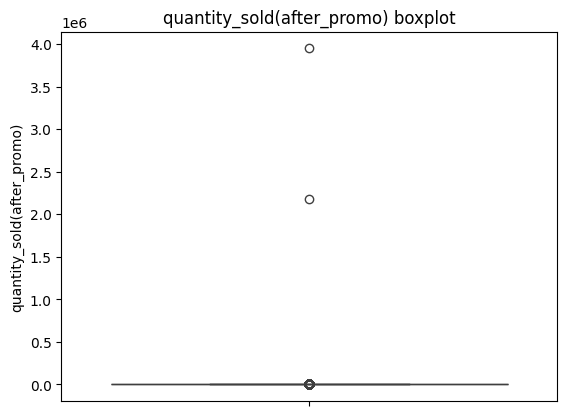

In [58]:
# checking for outliers in quantity_sold(after_promo) column with boxplot

plt.figure()
sns.boxplot(y=df_4["quantity_sold(after_promo)"])
plt.title("quantity_sold(after_promo) boxplot")
plt.show()

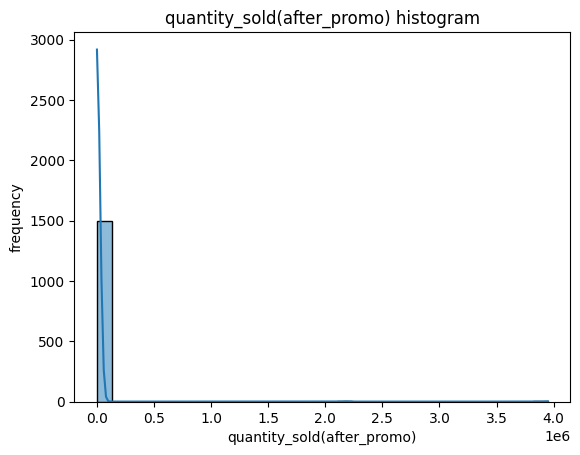

In [59]:
# checking for outliers in quantity_sold(after_promo) column with histogram

plt.figure()
sns.histplot(df_4["quantity_sold(after_promo)"], bins = 30, kde = True)
plt.title("quantity_sold(after_promo) histogram")
plt.xlabel("quantity_sold(after_promo)")
plt.ylabel("frequency")
plt.show()

In [60]:
df_4["quantity_sold(after_promo)"].max()

np.int64(3949605)

In [61]:
df_4.nlargest(10, "quantity_sold(after_promo)")

,event_id,store_id,campaign_id,product_code,base_price,promo_type,quantity_sold(before_promo),quantity_sold(after_promo)
1328,cc5ed4,STMYS-2,CAMP_DIW_01,P03,156,25% OFF,444,3949605
194,02fa4b,STVSK-4,CAMP_DIW_01,P01,172,33% OFF,155,2179782
687,e93b62,STCHE-2,CAMP_SAN_01,P04,370,BOGOF,513,2067
876,1a1a02,STBLR-0,CAMP_SAN_01,P04,370,BOGOF,465,2064
1394,fe94ae,STMYS-1,CAMP_SAN_01,P04,370,BOGOF,450,1984
596,4eb35e,STCHE-6,CAMP_SAN_01,P04,370,BOGOF,483,1907
492,fe7b5d,STHYD-2,CAMP_SAN_01,P03,200,BOGOF,472,1902
1409,0efde2,STCHE-7,CAMP_SAN_01,P03,200,BOGOF,448,1895
709,07e4ea,STHYD-6,CAMP_SAN_01,P04,370,BOGOF,486,1890
874,855f49,STBLR-3,CAMP_SAN_01,P04,370,BOGOF,481,1890


In [62]:
df_4["quantity_sold(after_promo)"].min()

np.int64(9)

In [63]:
df_4.nsmallest(10, "quantity_sold(after_promo)")

,event_id,store_id,campaign_id,product_code,base_price,promo_type,quantity_sold(before_promo),quantity_sold(after_promo)
455,f88523,STTRV-1,CAMP_SAN_01,P05,55,25% OFF,10,9
867,dafaa4,STVJD-1,CAMP_SAN_01,P05,55,25% OFF,13,9
1216,65a802,STMLR-1,CAMP_SAN_01,P05,55,25% OFF,13,10
1422,bed4b4,STMLR-1,CAMP_SAN_01,P10,50,25% OFF,13,10
860,5e59a1,STTRV-0,CAMP_SAN_01,P05,55,25% OFF,12,11
1144,0f714a,STVJD-1,CAMP_SAN_01,P06,415,25% OFF,16,11
1321,86196b,STTRV-0,CAMP_SAN_01,P06,415,25% OFF,13,11
66,7634c0,STMLR-0,CAMP_SAN_01,P10,50,25% OFF,15,12
100,8b751b,STMLR-0,CAMP_SAN_01,P05,55,25% OFF,15,12
356,94953c,STMLR-2,CAMP_SAN_01,P06,415,25% OFF,15,12


**From the above graphs and observation it is clear that there are high end outliers in quantity_sold(after_promo) column which are probably the result of wrong data entry. Instead of removing them it is better to replace the values with campaign and product code specific median values**

In [64]:
# Defining quantity_sold(after_promo) limits and creating a copy of the dataset

upper = 3000      # business logic and dataset observation

df_4_copy = df_4[
    (df_4["quantity_sold(after_promo)"] <= upper)
    ]

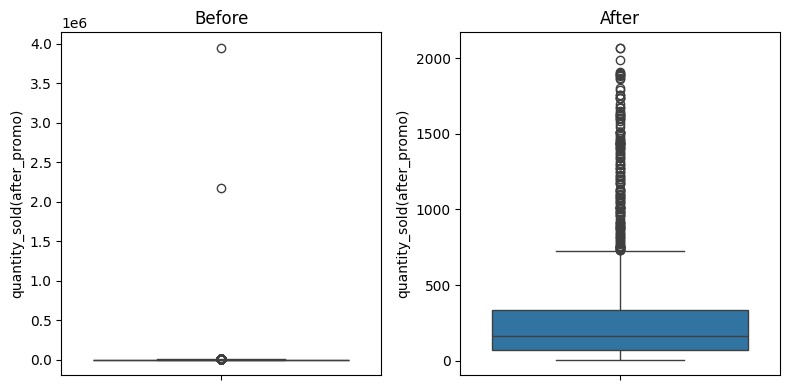

In [65]:
# before/after boxplot comparison

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
sns.boxplot(y=df_4["quantity_sold(after_promo)"])
plt.title("Before")

plt.subplot(1,2,2)
sns.boxplot(y=df_4_copy["quantity_sold(after_promo)"])
plt.title("After")

plt.tight_layout()
plt.show()

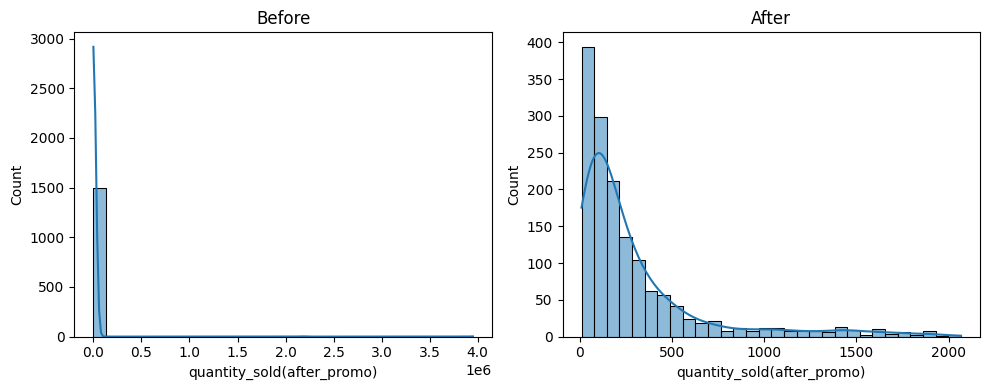

In [66]:
# before/after histogram comparison

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.histplot(df_4["quantity_sold(after_promo)"], bins=30, kde=True)
plt.title("Before")

plt.subplot(1,2,2)
sns.histplot(df_4_copy["quantity_sold(after_promo)"], bins=30, kde=True)
plt.title("After")

plt.tight_layout()
plt.show()

In [67]:
# flagging outlier values before imputing them

df_4["qty_after_outlier"] = (df_4["quantity_sold(after_promo)"] > upper)

In [68]:
df_4.nlargest(10, "quantity_sold(after_promo)")

,event_id,store_id,campaign_id,product_code,base_price,promo_type,quantity_sold(before_promo),quantity_sold(after_promo),qty_after_outlier
1328,cc5ed4,STMYS-2,CAMP_DIW_01,P03,156,25% OFF,444,3949605,True
194,02fa4b,STVSK-4,CAMP_DIW_01,P01,172,33% OFF,155,2179782,True
687,e93b62,STCHE-2,CAMP_SAN_01,P04,370,BOGOF,513,2067,False
876,1a1a02,STBLR-0,CAMP_SAN_01,P04,370,BOGOF,465,2064,False
1394,fe94ae,STMYS-1,CAMP_SAN_01,P04,370,BOGOF,450,1984,False
596,4eb35e,STCHE-6,CAMP_SAN_01,P04,370,BOGOF,483,1907,False
492,fe7b5d,STHYD-2,CAMP_SAN_01,P03,200,BOGOF,472,1902,False
1409,0efde2,STCHE-7,CAMP_SAN_01,P03,200,BOGOF,448,1895,False
709,07e4ea,STHYD-6,CAMP_SAN_01,P04,370,BOGOF,486,1890,False
874,855f49,STBLR-3,CAMP_SAN_01,P04,370,BOGOF,481,1890,False


In [69]:
# replacing the outlier values with campaign and product specific median values of quantity_sold(after_promo)

outlier_flag = df_4["qty_after_outlier"] == True

df_4.loc[outlier_flag, "quantity_sold(after_promo)"] = (
    df_4.groupby(["campaign_id", "product_code"])["quantity_sold(after_promo)"]
      .transform("median")[outlier_flag]
)

C:\Users\User\AppData\Local\Temp\ipykernel_20048\3090802704.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[424.5 271. ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_4.loc[outlier_flag, "quantity_sold(after_promo)"] = (


In [70]:
df_4[df_4["qty_after_outlier"] == True]

,event_id,store_id,campaign_id,product_code,base_price,promo_type,quantity_sold(before_promo),quantity_sold(after_promo),qty_after_outlier
194,02fa4b,STVSK-4,CAMP_DIW_01,P01,172,33% OFF,155,424.5,True
1328,cc5ed4,STMYS-2,CAMP_DIW_01,P03,156,25% OFF,444,271.0,True


In [71]:
df_4["quantity_sold(after_promo)"] = df_4["quantity_sold(after_promo)"].astype(int)

**Successfully flagged and handled the outliers. Also, changed the datatype to int.**

In [72]:
#last check of info overview of dim_customers

df_4.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1500 entries, 0 to 1499
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   event_id                     1500 non-null   object
 1   store_id                     1500 non-null   object
 2   campaign_id                  1500 non-null   object
 3   product_code                 1500 non-null   object
 4   base_price                   1500 non-null   int64 
 5   promo_type                   1500 non-null   object
 6   quantity_sold(before_promo)  1500 non-null   int64 
 7   quantity_sold(after_promo)   1500 non-null   int64 
 8   qty_after_outlier            1500 non-null   bool  
dtypes: bool(1), int64(3), object(5)
memory usage: 106.9+ KB


**fact_events has no more errors and is ready to import**

### Saving clean Datasets as csv

In [74]:
#dim_campaigns
df_1.to_csv("dim_campaigns_clean.csv", index = False)

#dim_products
df_2.to_csv("dim_products_clean.csv", index = False)

#dim_stores
df_3.to_csv("dim_stores_clean.csv", index = False)

#fact_events
df_4.to_csv("fact_events_clean.csv", index = False)

**Cleaned datasets saved as csv**

### Loading the datasets into the Database

In [75]:
from sqlalchemy import create_engine

# connecting to Postgresql

username = "postgres"
password = "SQL1234"
host = "localhost"
port = "5433"
database = "retail_db"

engine = create_engine(f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}")

# loading the Dataframes

dfs = {
    "dim_campaigns": df_1,
    "dim_products": df_2,
    "dim_stores" : df_3,
    "fact_events" : df_4
}

for table_name, df in dfs.items():
    df.to_sql(
        table_name,
        engine,
        if_exists="replace",
        index=False
    )
    print(f"{table_name} loaded in database {database}")

dim_campaigns loaded in database retail_db
dim_products loaded in database retail_db
dim_stores loaded in database retail_db
fact_events loaded in database retail_db


**Data Successfully loaded in Database**